# BNPL Usage by Income Group Analysis

This notebook analyzes Buy Now Pay Later (BNPL) usage patterns across different income groups using the Federal Reserve's Survey of Household Economics and Decisionmaking (SHED) 2024 data. The analysis calculates the percentage of people in each income group who use BNPL services and creates a visualization suitable for Tableau.

## Section 1: Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Section 2: Load and Explore the Data

In [ ]:
# Load the data
df = pd.read_csv('public2024.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

# Check for the relevant columns
print("\nColumn names (searching for BNPL and income variables):")
bnpl_cols = [col for col in df.columns if 'bnpl' in col.lower()]
income_cols = [col for col in df.columns if 'ppinc' in col.lower()]
print(f"BNPL columns: {bnpl_cols}")
print(f"Income columns: {income_cols}")

## Section 3: Filter and Prepare BNPL Data

In [ ]:
# Examine BNPL1 variable (Buy Now Pay Later usage)
print("BNPL1 Variable - Unique Values:")
print(df['BNPL1'].value_counts(dropna=False))
print(f"\nBNPL1 Data type: {df['BNPL1'].dtype}")
print(f"BNPL1 Missing values: {df['BNPL1'].isna().sum()}")

# Examine ppinc7 variable (income category)
print("\n" + "="*60)
print("ppinc7 Variable - Unique Values:")
print(df['ppinc7'].value_counts(dropna=False))
print(f"\nppinc7 Data type: {df['ppinc7'].dtype}")
print(f"ppinc7 Missing values: {df['ppinc7'].isna().sum()}")

# Create a working dataset with both variables
df_analysis = df[['BNPL1', 'ppinc7']].copy()

# Show value counts
print("\n" + "="*60)
print("Data availability for analysis:")
print(f"Total rows: {len(df_analysis)}")
print(f"Rows with BNPL1 data: {df_analysis['BNPL1'].notna().sum()}")
print(f"Rows with ppinc7 data: {df_analysis['ppinc7'].notna().sum()}")
print(f"Rows with both BNPL1 and ppinc7 data: {(df_analysis['BNPL1'].notna() & df_analysis['ppinc7'].notna()).sum()}")

## Section 4: Calculate BNPL Usage Percentage by Income Group

In [ ]:
# Filter data to only include complete cases
df_complete = df_analysis.dropna(subset=['BNPL1', 'ppinc7'])

# Convert BNPL1 to binary (1 = Yes, 0 = No)
# First, check what values mean "Yes" for BNPL usage
print("BNPL1 values in complete dataset:")
print(df_complete['BNPL1'].value_counts())

# Create a binary indicator for BNPL usage (1 = Yes, 0 = No)
df_complete['uses_bnpl'] = (df_complete['BNPL1'] == 'Yes').astype(int)

# Group by income category and calculate statistics
bnpl_by_income = df_complete.groupby('ppinc7').agg(
    total_respondents=('uses_bnpl', 'count'),
    bnpl_users=('uses_bnpl', 'sum'),
).reset_index()

# Calculate percentage
bnpl_by_income['bnpl_percentage'] = (bnpl_by_income['bnpl_users'] / bnpl_by_income['total_respondents'] * 100).round(2)

# Rename column for clarity
bnpl_by_income = bnpl_by_income.rename(columns={'ppinc7': 'income_group'})

# Sort by income group
print("BNPL Usage by Income Group:")
print(bnpl_by_income)

# Create a more readable version with additional formatting
bnpl_summary = bnpl_by_income.copy()
bnpl_summary['bnpl_percentage_str'] = bnpl_summary['bnpl_percentage'].astype(str) + '%'
print("\nFormatted Summary:")
print(bnpl_summary[['income_group', 'total_respondents', 'bnpl_users', 'bnpl_percentage_str']])

## Section 5: Create Visualization for Tableau Export

In [ ]:
# Create a professional stacked bar chart for Tableau export
fig, ax = plt.subplots(figsize=(14, 7))

# Calculate non-BNPL percentages
bnpl_by_income['non_bnpl_percentage'] = 100 - bnpl_by_income['bnpl_percentage']

# Create stacked bar plot
x = range(len(bnpl_by_income))
bars1 = ax.bar(x, bnpl_by_income['non_bnpl_percentage'], 
               label='Non-BNPL Users', color='#E63946', edgecolor='#A4161A', linewidth=1.5, alpha=0.85)
bars2 = ax.bar(x, bnpl_by_income['bnpl_percentage'], 
               bottom=bnpl_by_income['non_bnpl_percentage'],
               label='BNPL Users', color='#457B9D', edgecolor='#1B5E75', linewidth=1.5, alpha=0.85)

# Customize the plot
ax.set_xlabel('Income Group', fontsize=13, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=13, fontweight='bold')
ax.set_title('BNPL Usage by Income Group\nFED Survey of Household Economics and Decisionmaking (SHED) 2024', 
             fontsize=14, fontweight='bold', pad=20)

# Set x-axis labels
ax.set_xticks(x)
ax.set_xticklabels(bnpl_by_income['income_group'], rotation=45, ha='right', fontsize=10)

# Add percentage labels for BNPL users (blue section)
for i, (idx, row) in enumerate(bnpl_by_income.iterrows()):
    bnpl_pct = row['bnpl_percentage']
    non_bnpl_pct = row['non_bnpl_percentage']
    
    # Label for BNPL users (blue) - positioned in the middle of blue section
    ax.text(i, non_bnpl_pct + bnpl_pct/2, f'{bnpl_pct:.1f}%',
            ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    
    # Label for non-BNPL users (red) - positioned in the middle of red section
    ax.text(i, non_bnpl_pct/2, f'{non_bnpl_pct:.1f}%',
            ha='center', va='center', fontsize=11, fontweight='bold', color='white')

# Customize grid and layout
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.set_ylim(0, 105)
ax.legend(loc='upper right', fontsize=11, framealpha=0.95)

# Tight layout to prevent label cutoff
plt.tight_layout()

# Save the figure
plt.savefig('BNPL_by_income_group.png', dpi=300, bbox_inches='tight')
print("Chart saved as 'BNPL_by_income_group.png'")

plt.show()

## Section 6: Export Data to CSV for Tableau Import

In [7]:
# Export the analysis results to CSV for Tableau import
# Create a clean export version by selecting only the needed columns
export_data = bnpl_by_income[['income_group', 'total_respondents', 'bnpl_users', 'bnpl_percentage']].copy()
export_data.columns = ['Income Group', 'Total Respondents', 'BNPL Users', 'BNPL Usage Percentage']

# Save to CSV
csv_filename = 'bnpl_usage_by_income_group.csv'
export_data.to_csv(csv_filename, index=False)
print(f"Data exported to '{csv_filename}'")

# Display the final dataset
print("\n" + "="*80)
print("FINAL DATA FOR TABLEAU IMPORT")
print("="*80)
print(export_data.to_string(index=False))

# Summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(f"Total respondents with complete data: {export_data['Total Respondents'].sum():,}")
print(f"Total BNPL users: {export_data['BNPL Users'].sum():,}")
print(f"Overall BNPL usage percentage: {(export_data['BNPL Users'].sum() / export_data['Total Respondents'].sum() * 100):.2f}%")
print(f"\nIncome group with highest BNPL usage: {export_data.loc[export_data['BNPL Usage Percentage'].idxmax(), 'Income Group']} ({export_data['BNPL Usage Percentage'].max():.2f}%)")
print(f"Income group with lowest BNPL usage: {export_data.loc[export_data['BNPL Usage Percentage'].idxmin(), 'Income Group']} ({export_data['BNPL Usage Percentage'].min():.2f}%)")

Data exported to 'bnpl_usage_by_income_group.csv'

FINAL DATA FOR TABLEAU IMPORT
        Income Group  Total Respondents  BNPL Users  BNPL Usage Percentage
  $10,000 to $24,999                873         152                  17.41
$100,000 to $149,999               2375         304                  12.80
    $150,000 or more               3310         299                   9.03
  $25,000 to $49,999               1845         338                  18.32
  $50,000 to $74,999               1808         271                  14.99
  $75,000 to $99,999               1649         233                  14.13
   Less than $10,000                435          73                  16.78

SUMMARY STATISTICS
Total respondents with complete data: 12,295
Total BNPL users: 1,670
Overall BNPL usage percentage: 13.58%

Income group with highest BNPL usage: $25,000 to $49,999 (18.32%)
Income group with lowest BNPL usage: $150,000 or more (9.03%)


# BNPL Usage by Income Group Analysis

This notebook analyzes Buy Now Pay Later (BNPL) usage patterns across different income groups using the Federal Reserve's Survey of Household Economics and Decisionmaking (SHED) 2024 data. The analysis calculates the percentage of people in each income group who use BNPL services and creates a visualization suitable for Tableau.

## Section 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Section 2: Load and Explore the Data

In [2]:
# Load the data
df = pd.read_csv('public2024.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

# Check for the relevant columns
print("\nColumn names (searching for BNPL and income variables):")
bnpl_cols = [col for col in df.columns if 'bnpl' in col.lower()]
income_cols = [col for col in df.columns if 'ppinc' in col.lower()]
print(f"BNPL columns: {bnpl_cols}")
print(f"Income columns: {income_cols}")

Dataset Shape: (12295, 751)

First few rows:
      shedid  duration  weight  weight_pop  panel_weight  panel_weight_pop  \
0  202203873      1333  0.6149  12971.9817        1.2153        78509.7641   
1  202204577       975  0.8301  17511.2242           NaN               NaN   
2  201800189      2146  0.4447   9381.0980        0.8061        52078.4957   
3  202406204      1214  0.8333  17580.0326           NaN               NaN   
4  202200780      1168  0.9064  19121.3763           NaN               NaN   

  xlaptop L0_a L0_b L0_c  ... E4_f_iflag CH2A_iflag race_5cat  \
0      No   No   No   No  ...          0          0     White   
1      No   No   No   No  ...          0          0     White   
2      No   No   No   No  ...          0          0     White   
3      No  Yes   No   No  ...          0          0     White   
4      No  Yes   No   No  ...          0          0     White   

       inc_4cat_50k                                    educ_4cat pay_casheqv  \
0   $25,000–$49

## Section 3: Filter and Prepare BNPL Data

In [3]:
# Examine BNPL1 variable (Buy Now Pay Later usage)
print("BNPL1 Variable - Unique Values:")
print(df['BNPL1'].value_counts(dropna=False))
print(f"\nBNPL1 Data type: {df['BNPL1'].dtype}")
print(f"BNPL1 Missing values: {df['BNPL1'].isna().sum()}")

# Examine ppinc7 variable (income category)
print("\n" + "="*60)
print("ppinc7 Variable - Unique Values:")
print(df['ppinc7'].value_counts(dropna=False))
print(f"\nppinc7 Data type: {df['ppinc7'].dtype}")
print(f"ppinc7 Missing values: {df['ppinc7'].isna().sum()}")

# Create a working dataset with both variables
df_analysis = df[['BNPL1', 'ppinc7']].copy()

# Show value counts
print("\n" + "="*60)
print("Data availability for analysis:")
print(f"Total rows: {len(df_analysis)}")
print(f"Rows with BNPL1 data: {df_analysis['BNPL1'].notna().sum()}")
print(f"Rows with ppinc7 data: {df_analysis['ppinc7'].notna().sum()}")
print(f"Rows with both BNPL1 and ppinc7 data: {(df_analysis['BNPL1'].notna() & df_analysis['ppinc7'].notna()).sum()}")

BNPL1 Variable - Unique Values:
BNPL1
No     10625
Yes     1670
Name: count, dtype: int64

BNPL1 Data type: str
BNPL1 Missing values: 0

ppinc7 Variable - Unique Values:
ppinc7
$150,000 or more        3310
$100,000 to $149,999    2375
$25,000 to $49,999      1845
$50,000 to $74,999      1808
$75,000 to $99,999      1649
$10,000 to $24,999       873
Less than $10,000        435
Name: count, dtype: int64

ppinc7 Data type: str
ppinc7 Missing values: 0

Data availability for analysis:
Total rows: 12295
Rows with BNPL1 data: 12295
Rows with ppinc7 data: 12295
Rows with both BNPL1 and ppinc7 data: 12295


## Section 4: Calculate BNPL Usage Percentage by Income Group

In [4]:
# Filter data to only include complete cases
df_complete = df_analysis.dropna(subset=['BNPL1', 'ppinc7'])

# Convert BNPL1 to binary (1 = Yes, 0 = No)
# First, check what values mean "Yes" for BNPL usage
print("BNPL1 values in complete dataset:")
print(df_complete['BNPL1'].value_counts())

# Create a binary indicator for BNPL usage (1 = Yes, 0 = No)
df_complete['uses_bnpl'] = (df_complete['BNPL1'] == 'Yes').astype(int)

# Group by income category and calculate statistics
bnpl_by_income = df_complete.groupby('ppinc7').agg(
    total_respondents=('uses_bnpl', 'count'),
    bnpl_users=('uses_bnpl', 'sum'),
).reset_index()

# Calculate percentage
bnpl_by_income['bnpl_percentage'] = (bnpl_by_income['bnpl_users'] / bnpl_by_income['total_respondents'] * 100).round(2)

# Rename column for clarity
bnpl_by_income = bnpl_by_income.rename(columns={'ppinc7': 'income_group'})

# Sort by income group
print("BNPL Usage by Income Group:")
print(bnpl_by_income)

# Create a more readable version with additional formatting
bnpl_summary = bnpl_by_income.copy()
bnpl_summary['bnpl_percentage_str'] = bnpl_summary['bnpl_percentage'].astype(str) + '%'
print("\nFormatted Summary:")
print(bnpl_summary[['income_group', 'total_respondents', 'bnpl_users', 'bnpl_percentage_str']])

BNPL1 values in complete dataset:
BNPL1
No     10625
Yes     1670
Name: count, dtype: int64
BNPL Usage by Income Group:
           income_group  total_respondents  bnpl_users  bnpl_percentage
0    $10,000 to $24,999                873         152            17.41
1  $100,000 to $149,999               2375         304            12.80
2      $150,000 or more               3310         299             9.03
3    $25,000 to $49,999               1845         338            18.32
4    $50,000 to $74,999               1808         271            14.99
5    $75,000 to $99,999               1649         233            14.13
6     Less than $10,000                435          73            16.78

Formatted Summary:
           income_group  total_respondents  bnpl_users bnpl_percentage_str
0    $10,000 to $24,999                873         152              17.41%
1  $100,000 to $149,999               2375         304               12.8%
2      $150,000 or more               3310         299     

## Section 5: Create Visualization for Tableau Export

Chart saved as 'BNPL_by_income_group.png'


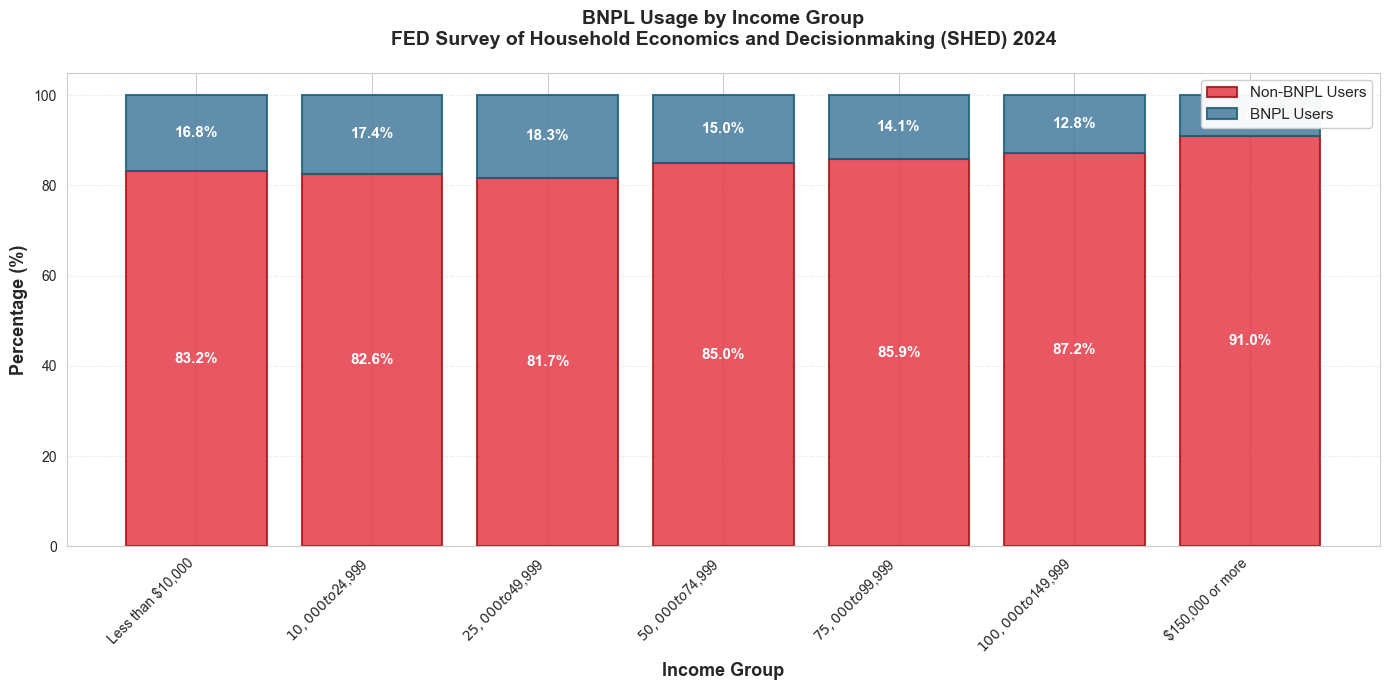

In [12]:
# Create a professional stacked bar chart for Tableau export
fig, ax = plt.subplots(figsize=(14, 7))

# Calculate non-BNPL percentages
bnpl_by_income['non_bnpl_percentage'] = 100 - bnpl_by_income['bnpl_percentage']

# Define income order from smallest to largest
income_order = [
    'Less than $10,000',
    '$10,000 to $24,999',
    '$25,000 to $49,999',
    '$50,000 to $74,999',
    '$75,000 to $99,999',
    '$100,000 to $149,999',
    '$150,000 or more'
]

# Convert income_group to categorical with custom order and sort
bnpl_by_income['income_group'] = pd.Categorical(bnpl_by_income['income_group'], categories=income_order, ordered=True)
bnpl_by_income = bnpl_by_income.sort_values('income_group').reset_index(drop=True)

# Create stacked bar plot
x = range(len(bnpl_by_income))
bars1 = ax.bar(x, bnpl_by_income['non_bnpl_percentage'], 
               label='Non-BNPL Users', color='#E63946', edgecolor='#A4161A', linewidth=1.5, alpha=0.85)
bars2 = ax.bar(x, bnpl_by_income['bnpl_percentage'], 
               bottom=bnpl_by_income['non_bnpl_percentage'],
               label='BNPL Users', color='#457B9D', edgecolor='#1B5E75', linewidth=1.5, alpha=0.85)

# Customize the plot
ax.set_xlabel('Income Group', fontsize=13, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=13, fontweight='bold')
ax.set_title('BNPL Usage by Income Group\nFED Survey of Household Economics and Decisionmaking (SHED) 2024', 
             fontsize=14, fontweight='bold', pad=20)

# Set x-axis labels
ax.set_xticks(x)
ax.set_xticklabels(bnpl_by_income['income_group'], rotation=45, ha='right', fontsize=10)

# Add percentage labels for BNPL users (blue section)
for i, (idx, row) in enumerate(bnpl_by_income.iterrows()):
    bnpl_pct = row['bnpl_percentage']
    non_bnpl_pct = row['non_bnpl_percentage']
    
    # Label for BNPL users (blue) - positioned in the middle of blue section
    ax.text(i, non_bnpl_pct + bnpl_pct/2, f'{bnpl_pct:.1f}%',
            ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    
    # Label for non-BNPL users (red) - positioned in the middle of red section
    ax.text(i, non_bnpl_pct/2, f'{non_bnpl_pct:.1f}%',
            ha='center', va='center', fontsize=11, fontweight='bold', color='white')

# Customize grid and layout
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.set_ylim(0, 105)
ax.legend(loc='upper right', fontsize=11, framealpha=0.95)

# Tight layout to prevent label cutoff
plt.tight_layout()

# Save the figure
plt.savefig('BNPL_by_income_group.png', dpi=300, bbox_inches='tight')
print("Chart saved as 'BNPL_by_income_group.png'")

plt.show()

## Section 6: Export Data to CSV for Tableau Import

In [9]:
# Export the analysis results to CSV for Tableau import
# Create a clean export version by selecting only the needed columns
export_data = bnpl_by_income[['income_group', 'total_respondents', 'bnpl_users', 'bnpl_percentage']].copy()
export_data.columns = ['Income Group', 'Total Respondents', 'BNPL Users', 'BNPL Usage Percentage']

# Save to CSV
csv_filename = 'bnpl_usage_by_income_group.csv'
export_data.to_csv(csv_filename, index=False)
print(f"Data exported to '{csv_filename}'")

# Display the final dataset
print("\n" + "="*80)
print("FINAL DATA FOR TABLEAU IMPORT")
print("="*80)
print(export_data.to_string(index=False))

# Summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(f"Total respondents with complete data: {export_data['Total Respondents'].sum():,}")
print(f"Total BNPL users: {export_data['BNPL Users'].sum():,}")
print(f"Overall BNPL usage percentage: {(export_data['BNPL Users'].sum() / export_data['Total Respondents'].sum() * 100):.2f}%")
print(f"\nIncome group with highest BNPL usage: {export_data.loc[export_data['BNPL Usage Percentage'].idxmax(), 'Income Group']} ({export_data['BNPL Usage Percentage'].max():.2f}%)")
print(f"Income group with lowest BNPL usage: {export_data.loc[export_data['BNPL Usage Percentage'].idxmin(), 'Income Group']} ({export_data['BNPL Usage Percentage'].min():.2f}%)")

Data exported to 'bnpl_usage_by_income_group.csv'

FINAL DATA FOR TABLEAU IMPORT
        Income Group  Total Respondents  BNPL Users  BNPL Usage Percentage
  $10,000 to $24,999                873         152                  17.41
$100,000 to $149,999               2375         304                  12.80
    $150,000 or more               3310         299                   9.03
  $25,000 to $49,999               1845         338                  18.32
  $50,000 to $74,999               1808         271                  14.99
  $75,000 to $99,999               1649         233                  14.13
   Less than $10,000                435          73                  16.78

SUMMARY STATISTICS
Total respondents with complete data: 12,295
Total BNPL users: 1,670
Overall BNPL usage percentage: 13.58%

Income group with highest BNPL usage: $25,000 to $49,999 (18.32%)
Income group with lowest BNPL usage: $150,000 or more (9.03%)


In [11]:
## Section 7: Reshape Data to Long Format for Alternative Format

# Create a long format version (one row per income group per BNPL status)
# This matches the format of ppagedcat with Yes/No rows
long_format_data = []

for idx, row in bnpl_by_income.iterrows():
    income_group = row['income_group']
    total = row['total_respondents']
    bnpl_count = row['bnpl_users']
    non_bnpl_count = total - bnpl_count
    bnpl_pct = row['bnpl_percentage']
    non_bnpl_pct = 100 - bnpl_pct
    
    # Add "Yes" row
    long_format_data.append({
        'ppinc7': income_group,
        'Used_BNPL': 'Yes',
        'count': bnpl_count,
        'percent': round(bnpl_pct, 2)
    })
    
    # Add "No" row
    long_format_data.append({
        'ppinc7': income_group,
        'Used_BNPL': 'No',
        'count': non_bnpl_count,
        'percent': round(non_bnpl_pct, 2)
    })

# Create DataFrame from long format data
long_format_df = pd.DataFrame(long_format_data)

# Define custom sort order for income groups (lowest to highest)
income_order = [
    'Less than $10,000',
    '$10,000 to $24,999',
    '$25,000 to $49,999',
    '$50,000 to $74,999',
    '$75,000 to $99,999',
    '$100,000 to $149,999',
    '$150,000 or more'
]

# Convert ppinc7 to categorical with custom order
long_format_df['ppinc7'] = pd.Categorical(long_format_df['ppinc7'], categories=income_order, ordered=True)

# Sort by income group
long_format_df = long_format_df.sort_values('ppinc7').reset_index(drop=True)

# Save to CSV
long_format_filename = 'bnpl_usage_by_income_group_long.csv'
long_format_df.to_csv(long_format_filename, index=False)
print(f"Long format data exported to '{long_format_filename}'")

# Display the data
print("\n" + "="*80)
print("LONG FORMAT DATA (SIMILAR TO AGE GROUP FORMAT) - SORTED BY INCOME")
print("="*80)
print(long_format_df.to_string(index=False))

Long format data exported to 'bnpl_usage_by_income_group_long.csv'

LONG FORMAT DATA (SIMILAR TO AGE GROUP FORMAT) - SORTED BY INCOME
              ppinc7 Used_BNPL  count  percent
   Less than $10,000       Yes     73    16.78
   Less than $10,000        No    362    83.22
  $10,000 to $24,999       Yes    152    17.41
  $10,000 to $24,999        No    721    82.59
  $25,000 to $49,999       Yes    338    18.32
  $25,000 to $49,999        No   1507    81.68
  $50,000 to $74,999       Yes    271    14.99
  $50,000 to $74,999        No   1537    85.01
  $75,000 to $99,999       Yes    233    14.13
  $75,000 to $99,999        No   1416    85.87
$100,000 to $149,999       Yes    304    12.80
$100,000 to $149,999        No   2071    87.20
    $150,000 or more       Yes    299     9.03
    $150,000 or more        No   3011    90.97
